# 2026-08-28 Pre-peak individual-galaxy SF-fraction diagnostics

This notebook focuses only on the **pre-peak** galaxies from the primary sample used in `20260827_check_SF_fraction.ipynb` (science-ready products and $i<80^\circ$).

For each galaxy it shows:

1. $f_{\rm SF}(\Sigma_\star)$ versus $\log\Sigma_\star$;
2. $f_{\rm SF}(R/R_e)$ versus $R/R_e$;
3. $\log\Sigma_\star$ versus $R/R_e$, with separate median trends for all valid disc pixels and for the selected star-forming pixels.

It then reproduces the stellar-mass-map inspection style of cell 7 in `20260820_initial_check_rSFMS_rMZR_galaxy_weighted_by_galaxy_Re.ipynb` for the pre-peak sample only, retaining the red $R_e$ boundary and adding a yellow $\log\Sigma_\star=7.5$ contour.

The SF selection is unchanged from the 2026-08-27 source notebook: finite H II SFR, $\mathrm{EW}(\mathrm{H}\alpha)>6$ Å, and intrinsic $\sigma_{\mathrm{H}\alpha}<45\,\mathrm{km\,s^{-1}}$. No extra inclination correction is applied to the surface-density maps.

## 1. Configuration and imports

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_EDGES = np.linspace(6.0, 10.0, 13)
R_EDGES = np.arange(0.0, 1.6 + 0.2, 0.2)
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print("Scope: pre-peak, science-ready primary sample with inclination < 80 deg")
print("No additional inclination correction is applied to either surface-density map.")

Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: pre-peak, science-ready primary sample with inclination < 80 deg
No additional inclination correction is applied to either surface-density map.


## 2. Reusable data and measurement helpers

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data


def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)


def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)


def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247


def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result


def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    shapes = {a.shape for a in (mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr)}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    return {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }


def binned_fraction(values, valid_mask, selected_mask, edges, min_valid=MIN_VALID_PIXELS_PER_BIN):
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
        n_valid = int((valid_mask & in_bin).sum())
        n_selected = int((selected_mask & in_bin).sum())
        rows.append({
            "center": (lo + hi) / 2,
            "N_valid": n_valid,
            "N_SF": n_selected,
            "f_SF": n_selected / n_valid if n_valid >= min_valid else np.nan,
        })
    return pd.DataFrame(rows)


def radial_mass_trends(maps, edges):
    radius = maps["radius_re"]
    mass = maps["log_sigma_star"]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(radius) & (radius >= lo) & (radius < hi)
        all_pixels = maps["valid_disc_mask"] & in_bin
        sf_pixels = maps["sf_mask"] & in_bin
        n_all, n_sf = int(all_pixels.sum()), int(sf_pixels.sum())
        rows.append({
            "radius_center": (lo + hi) / 2,
            "N_all": n_all,
            "N_SF": n_sf,
            "all_median": np.nanmedian(mass[all_pixels]) if n_all >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "sf_median": np.nanmedian(mass[sf_pixels]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(rows)

## 3. Live pre-peak inventory and QC

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir() if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS]),
            "ew_path": first_existing([folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
        })
    return pd.DataFrame(rows)


master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg", "center_dec_deg",
    "inclination_deg", "pa_deg_east_of_north", "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left", validate="one_to_one"
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
prepeak_candidates = inventory.loc[
    inventory.stage.eq("pre-peak") & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values("GALID").reset_index(drop=True)

map_cache = {}
qc_rows = []
for row in prepeak_candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path), ("ew", row.ew_path), ("mask", row.mask_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            if np.any(maps["sf_mask"] & ~maps["valid_disc_mask"]):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        map_cache[row.GALID] = maps
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid_stellar_pixels": int(maps["valid_disc_mask"].sum()) if maps is not None else 0,
        "N_selected_SF_pixels": int(maps["sf_mask"].sum()) if maps is not None else 0,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"] if maps is not None else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })

PREPEAK_QC = pd.DataFrame(qc_rows)
prepeak = prepeak_candidates.loc[
    prepeak_candidates.GALID.isin(PREPEAK_QC.loc[PREPEAK_QC.QC_flag.eq("OK"), "GALID"])
].copy()

display(PREPEAK_QC)
print(f"Pre-peak primary products passing QC: {len(prepeak)}/{len(prepeak_candidates)}")
print("Included:", ", ".join(prepeak.GALID))
if len(prepeak) == 0:
    raise RuntimeError("No pre-peak galaxies passed the live product QC")

,GALID,components,stage,inclination_deg,N_valid_stellar_pixels,N_selected_SF_pixels,wcs_separation_arcsec,QC_flag
0,NGC4189,NGC4189,pre-peak,42.0,177204,96364,0.0,OK
1,NGC4254,NGC4254,pre-peak,39.0,1043477,661963,0.0,OK
2,NGC4294,NGC4294,pre-peak,74.0,179355,68833,0.0,OK
3,NGC4321,NGC4321,pre-peak,32.0,970159,454131,0.0,OK
4,NGC4351,NGC4351,pre-peak,48.0,180133,30711,0.0,OK
5,NGC4383,NGC4383,pre-peak,56.0,227031,25212,0.0,OK
6,NGC4535,NGC4535,pre-peak,48.0,525101,187113,0.0,OK
7,NGC4567_8,"NGC4567,NGC4568",pre-peak,70.0,510118,222533,0.0,OK


Pre-peak primary products passing QC: 8/8
Included: NGC4189, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4535, NGC4567_8


## 4. Three side-by-side diagnostics for each pre-peak galaxy

The first two panels use the same minimum denominator as the source SF-fraction notebook: a bin is shown only with at least 50 valid disc pixels. In the third panel, the all-pixel median requires at least 50 valid pixels and the selected-SF median requires at least 20 SF pixels.

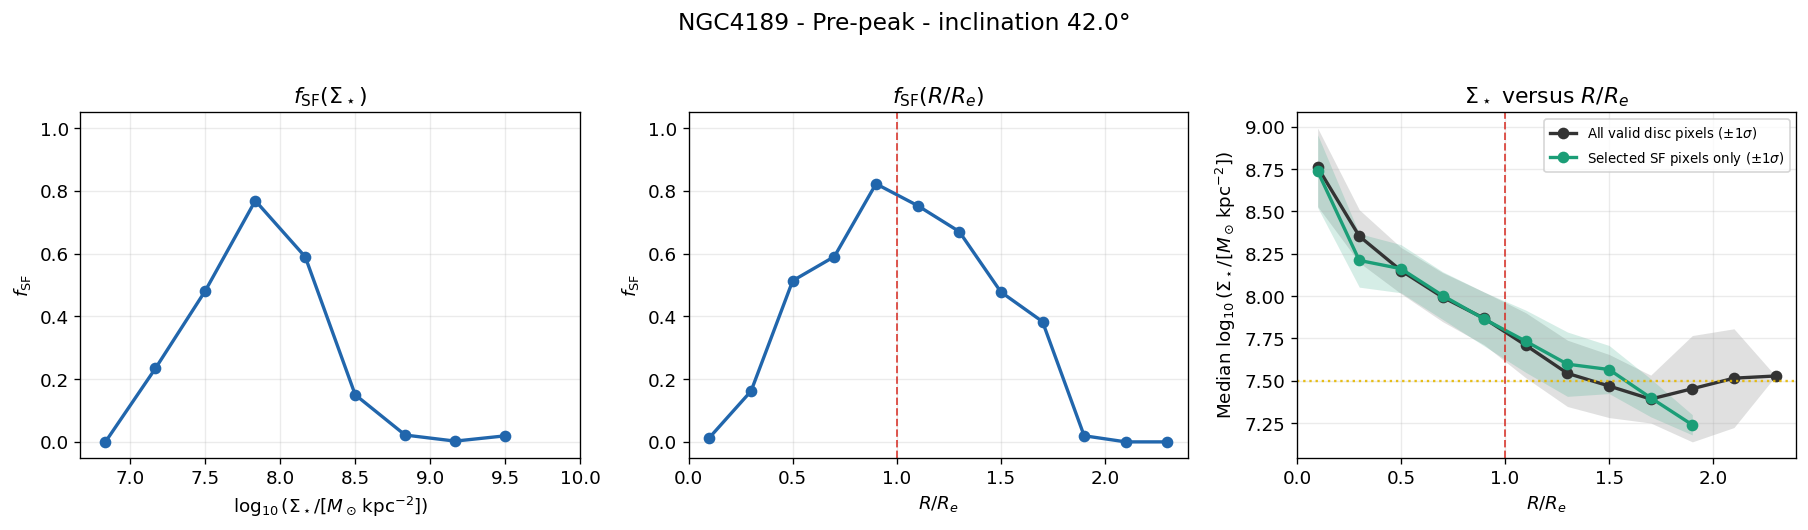

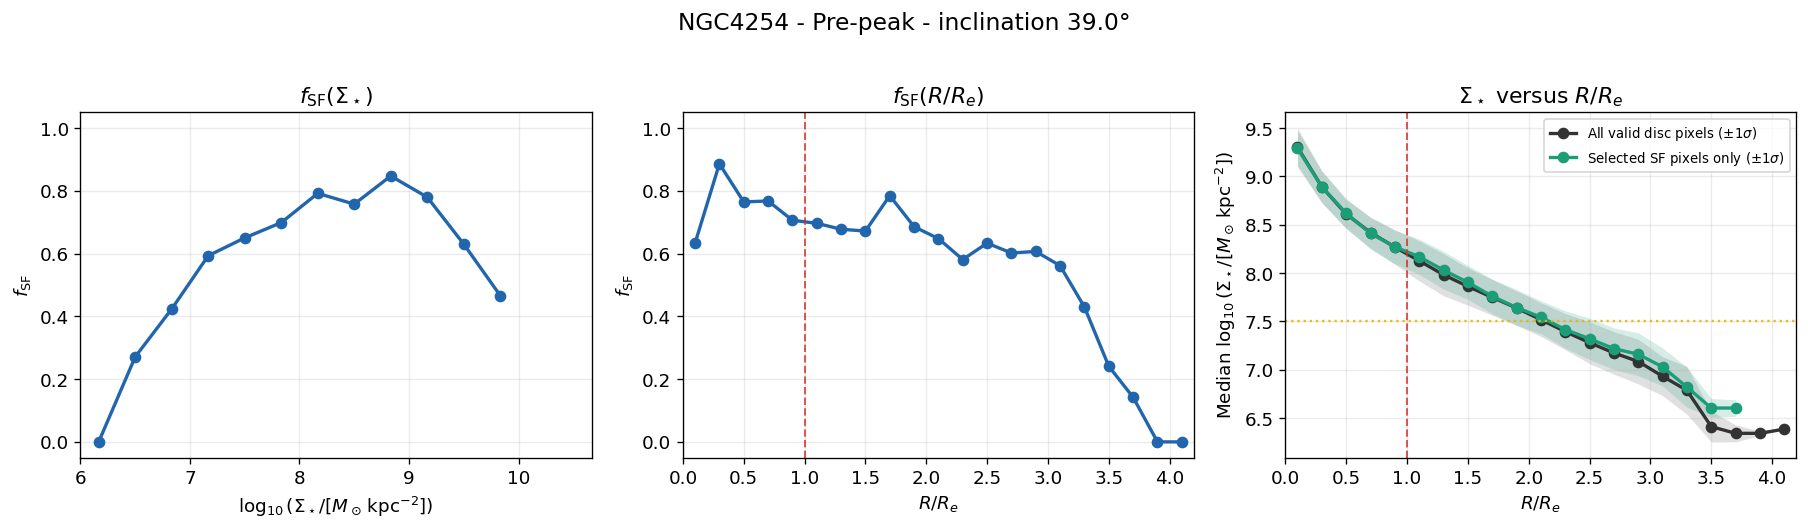

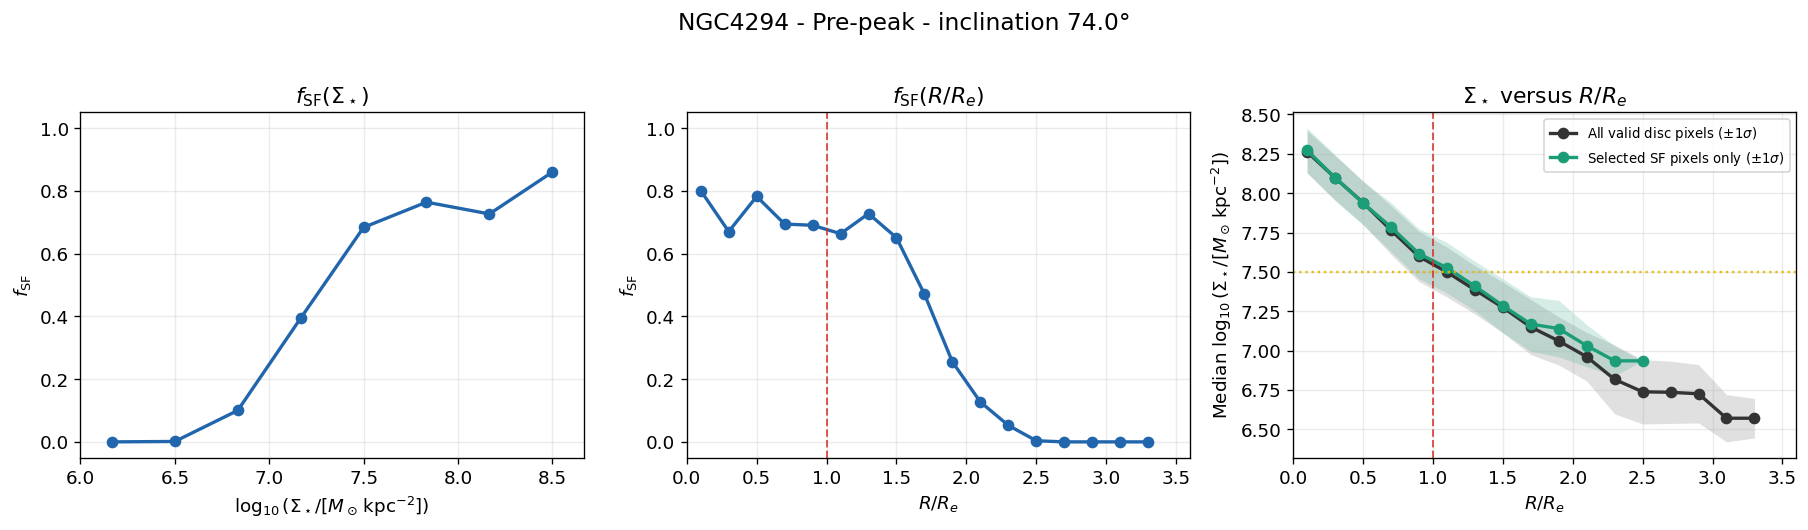

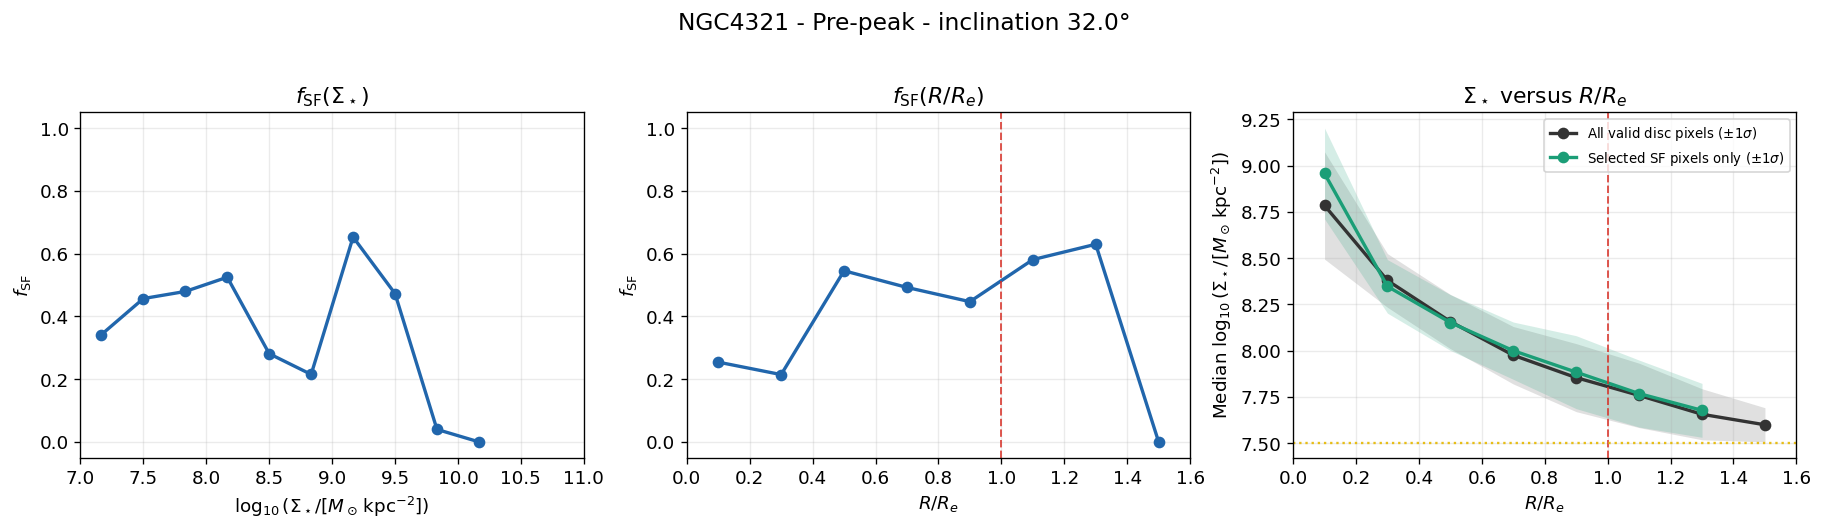

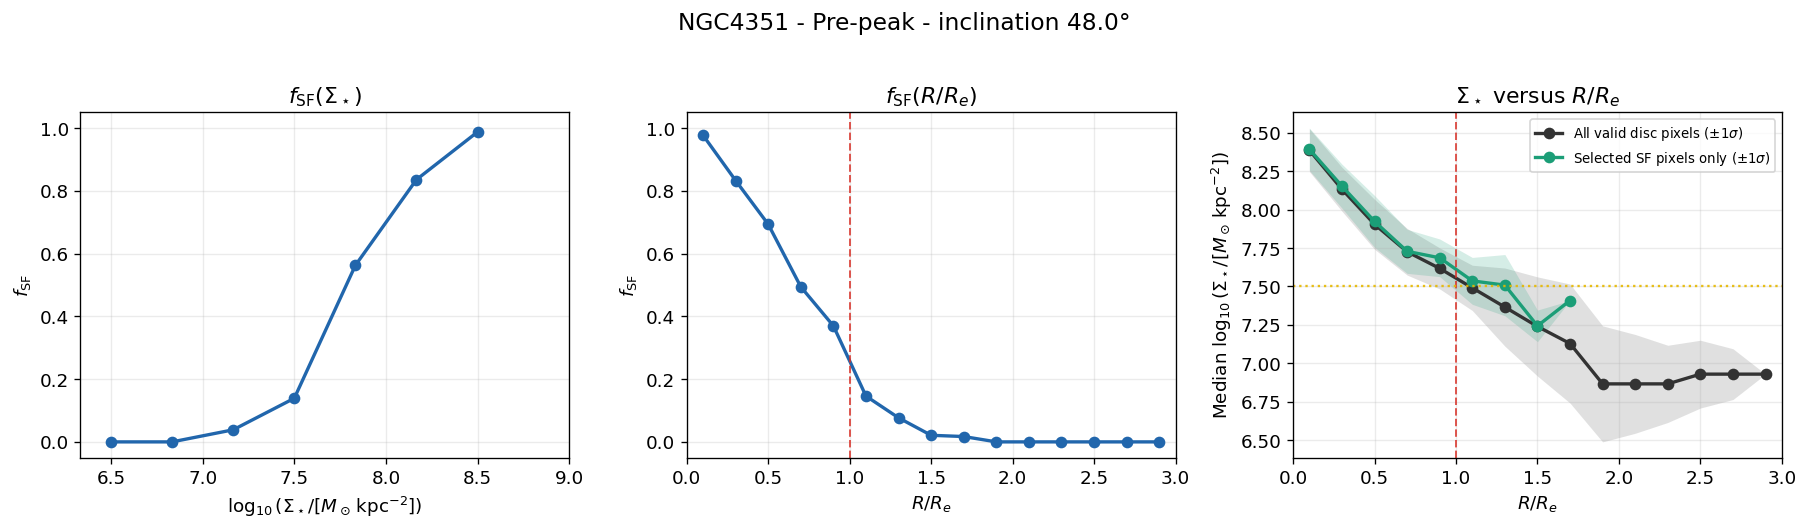

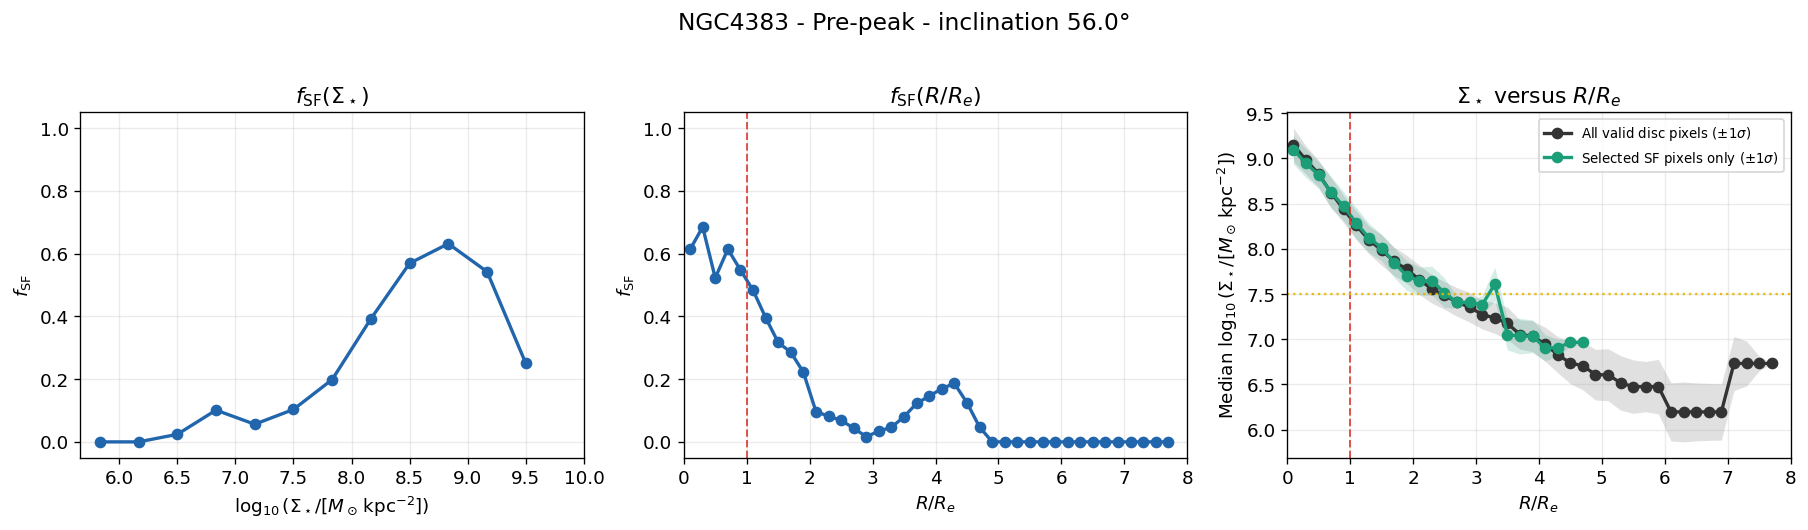

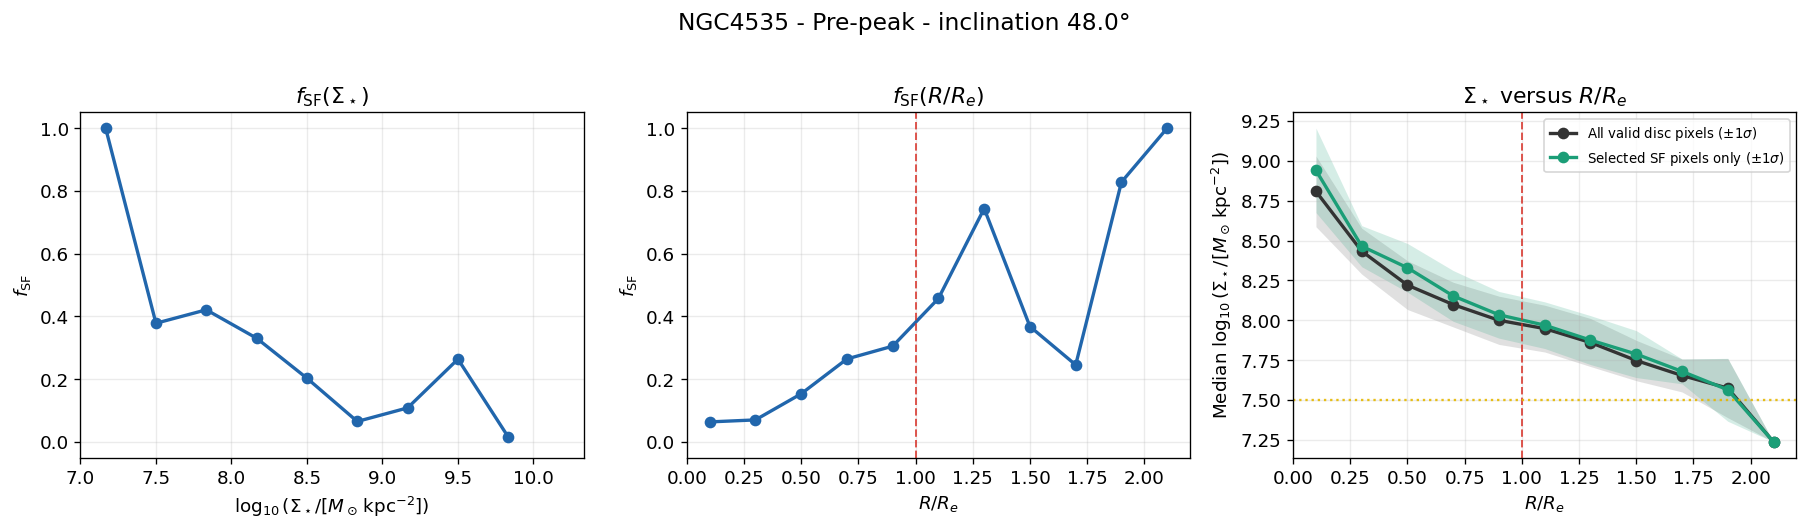

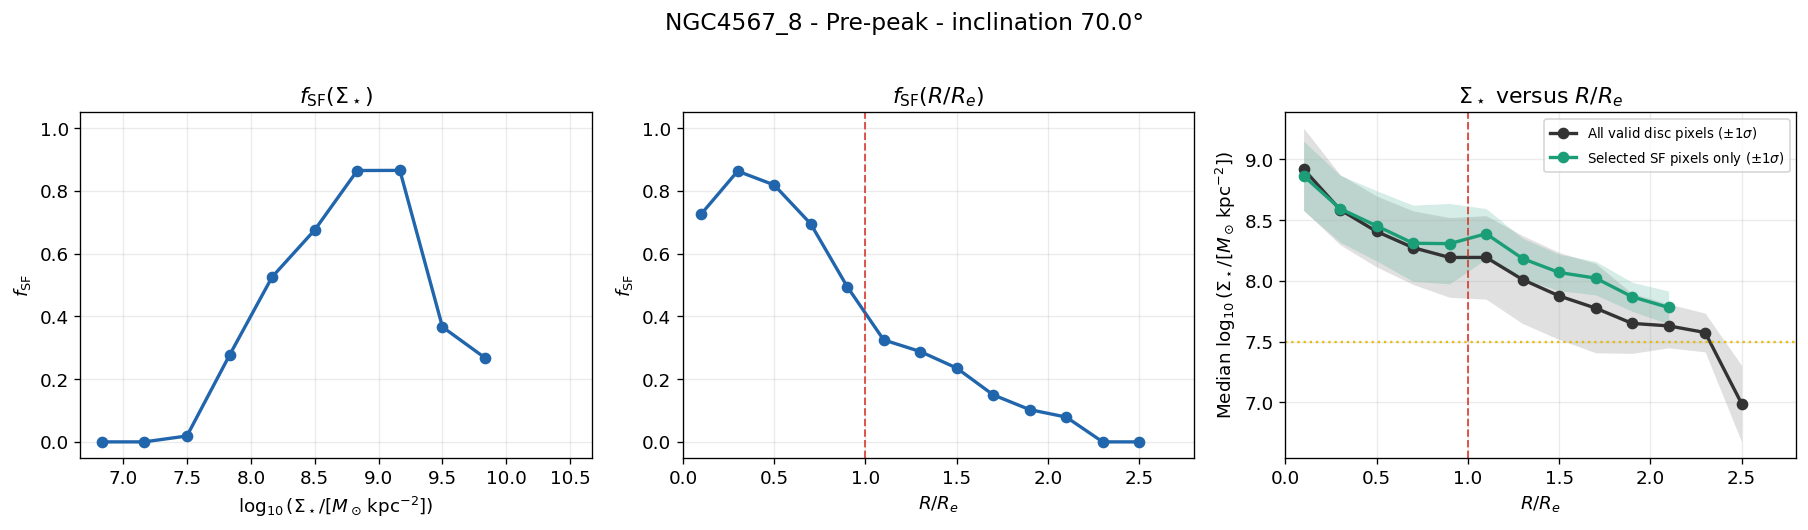

In [4]:
individual_measurements = {}


def complete_bin_edges(values, valid_mask, bin_width, *, lower_limit=None):
    """Return aligned edges that include the full finite range of valid values."""
    finite_values = np.asarray(values, dtype=float)[valid_mask & np.isfinite(values)]
    if finite_values.size == 0:
        raise ValueError("Cannot construct bins from an empty valid range")
    data_min = float(np.nanmin(finite_values))
    data_max = float(np.nanmax(finite_values))
    start = (
        float(lower_limit)
        if lower_limit is not None
        else np.floor(data_min / bin_width) * bin_width
    )
    stop = (np.floor(data_max / bin_width) + 1.0) * bin_width
    return np.arange(start, stop + 0.5 * bin_width, bin_width)


SIGMA_BIN_WIDTH = float(np.median(np.diff(SIGMA_EDGES)))
RADIUS_BIN_WIDTH = float(np.median(np.diff(R_EDGES)))

for row in prepeak.itertuples(index=False):
    maps = map_cache[row.GALID]
    galaxy_sigma_edges = complete_bin_edges(
        maps["log_sigma_star"], maps["valid_disc_mask"], SIGMA_BIN_WIDTH
    )
    galaxy_radius_edges = complete_bin_edges(
        maps["radius_re"], maps["valid_disc_mask"], RADIUS_BIN_WIDTH, lower_limit=0.0
    )
    by_sigma = binned_fraction(
        maps["log_sigma_star"], maps["valid_disc_mask"], maps["sf_mask"], galaxy_sigma_edges
    )
    by_radius = binned_fraction(
        maps["radius_re"], maps["valid_disc_mask"], maps["sf_mask"], galaxy_radius_edges
    )
    mass_by_radius = radial_mass_trends(maps, galaxy_radius_edges)

    # For the mass-radius panel, calculate the actual scatter in log Sigma_star
    # independently for all valid pixels and for selected SF pixels.
    all_std, sf_std = [], []
    radius = maps["radius_re"]
    mass = maps["log_sigma_star"]
    for lo, hi in zip(galaxy_radius_edges[:-1], galaxy_radius_edges[1:]):
        in_bin = np.isfinite(radius) & (radius >= lo) & (radius < hi)
        all_pixels = maps["valid_disc_mask"] & in_bin
        sf_pixels = maps["sf_mask"] & in_bin
        all_std.append(
            np.nanstd(mass[all_pixels], ddof=1)
            if int(all_pixels.sum()) >= MIN_VALID_PIXELS_PER_BIN else np.nan
        )
        sf_std.append(
            np.nanstd(mass[sf_pixels], ddof=1)
            if int(sf_pixels.sum()) >= MIN_SF_PIXELS_PER_BIN else np.nan
        )
    mass_by_radius["all_std"] = all_std
    mass_by_radius["sf_std"] = sf_std

    individual_measurements[row.GALID] = {
        "fSF_by_sigma": by_sigma,
        "fSF_by_radius": by_radius,
        "mass_by_radius": mass_by_radius,
        "sigma_edges": galaxy_sigma_edges,
        "radius_edges": galaxy_radius_edges,
    }

    fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.3))
    fig.suptitle(
        f"{row.GALID} - Pre-peak - inclination {row.inclination:.1f}°",
        fontsize=14, y=1.02,
    )

    axes[0].plot(by_sigma.center, by_sigma.f_SF, marker="o", lw=2.0, color="#2166ac")
    axes[0].set(
        xlabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        ylabel=r"$f_{\rm SF}$",
        title=r"$f_{\rm SF}(\Sigma_\star)$",
        xlim=(galaxy_sigma_edges[0], galaxy_sigma_edges[-1]), ylim=(-0.05, 1.05),
    )
    axes[1].plot(by_radius.center, by_radius.f_SF, marker="o", lw=2.0, color="#2166ac")
    axes[1].set(
        xlabel=r"$R/R_e$", ylabel=r"$f_{\rm SF}$",
        title=r"$f_{\rm SF}(R/R_e)$",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]), ylim=(-0.05, 1.05),
    )
    axes[1].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8)
    axes[2].fill_between(
        mass_by_radius.radius_center,
        mass_by_radius.all_median - mass_by_radius.all_std,
        mass_by_radius.all_median + mass_by_radius.all_std,
        color="0.2", alpha=0.15, linewidth=0,
    )
    axes[2].fill_between(
        mass_by_radius.radius_center,
        mass_by_radius.sf_median - mass_by_radius.sf_std,
        mass_by_radius.sf_median + mass_by_radius.sf_std,
        color="#1b9e77", alpha=0.18, linewidth=0,
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.all_median,
        marker="o", lw=2.0, color="0.2", label=r"All valid disc pixels ($\pm1\sigma$)",
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.sf_median,
        marker="o", lw=2.0, color="#1b9e77", label=r"Selected SF pixels only ($\pm1\sigma$)",
    )
    axes[2].set(
        xlabel=r"$R/R_e$",
        ylabel=r"Median $\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        title=r"$\Sigma_\star$ versus $R/R_e$",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]),
    )
    axes[2].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8)
    axes[2].axhline(MASS_CONTOUR_LEVEL, color="#e6b800", ls=":", lw=1.4, alpha=0.9)
    axes[2].legend(fontsize=8)

    for axis in axes:
        axis.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

### Interpretation guide

- $f_{\rm SF}$ is the fraction of valid disc pixels in the bin that pass the unchanged H II + EW + intrinsic-dispersion SF selection.
- The third panel compares like-for-like radial bins within the same galaxy. A separation between the black and green tracks indicates that the selected SF pixels occupy a different $\Sigma_\star$ distribution from the full valid disc footprint at that radius.
- The dashed vertical line marks $R/R_e=1$; the dotted yellow horizontal guide marks $\log\Sigma_\star=7.5$, matching the contour used below.

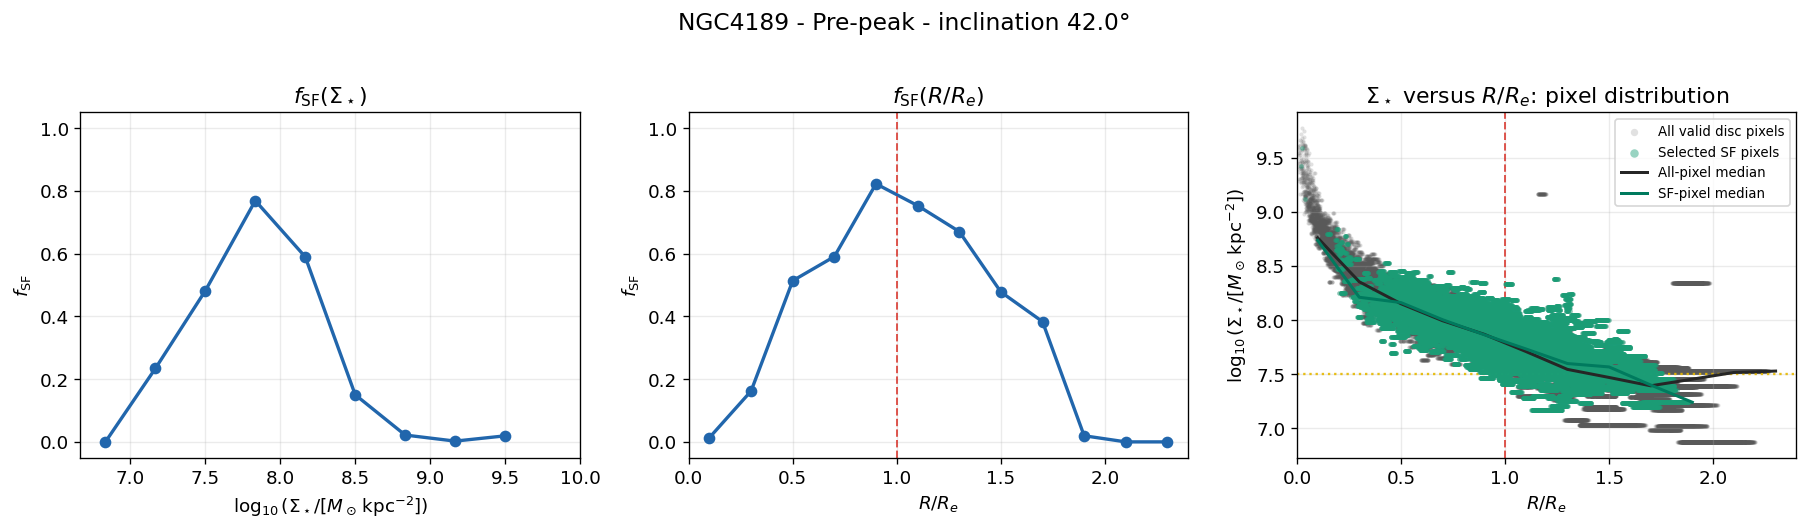

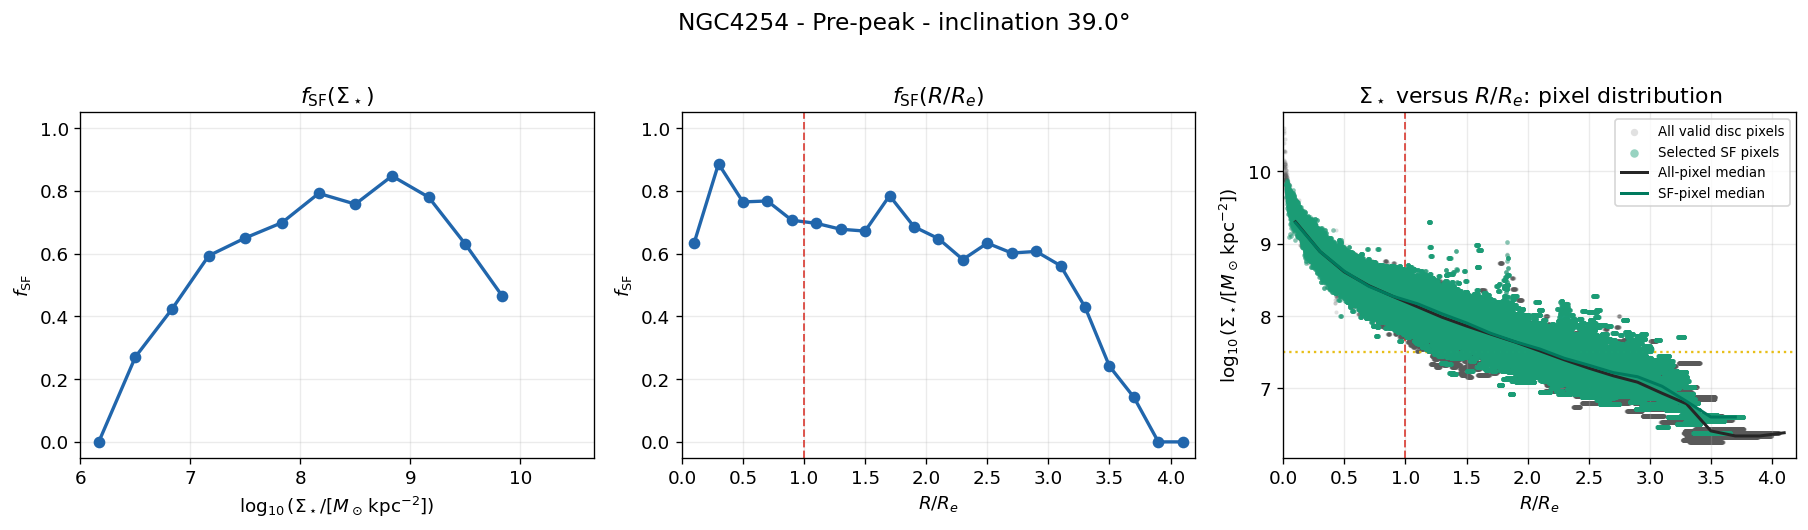

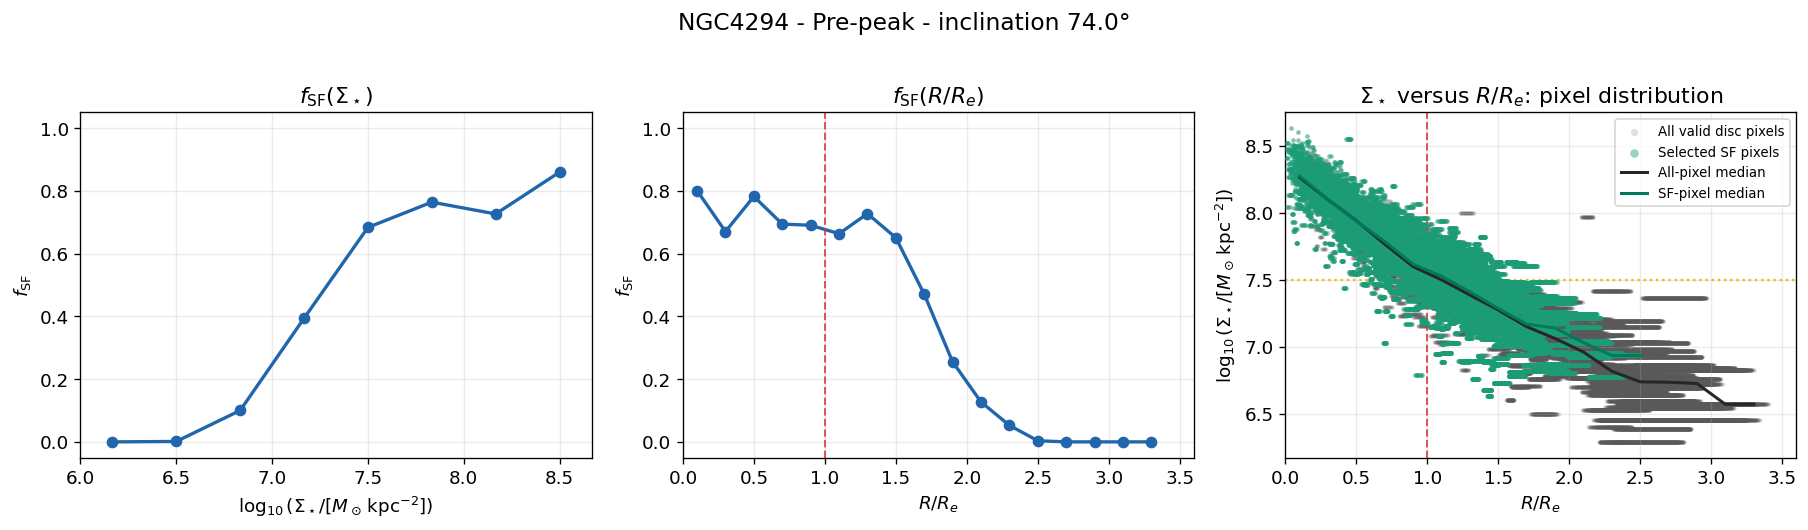

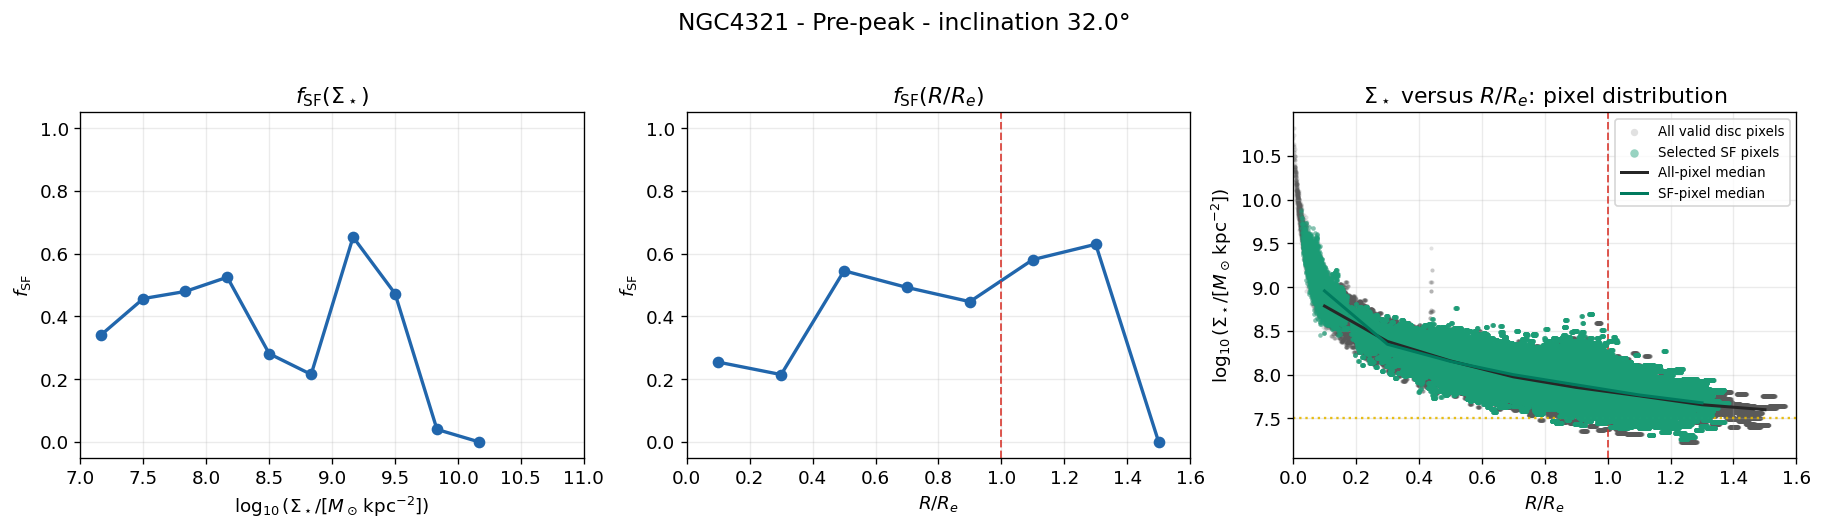

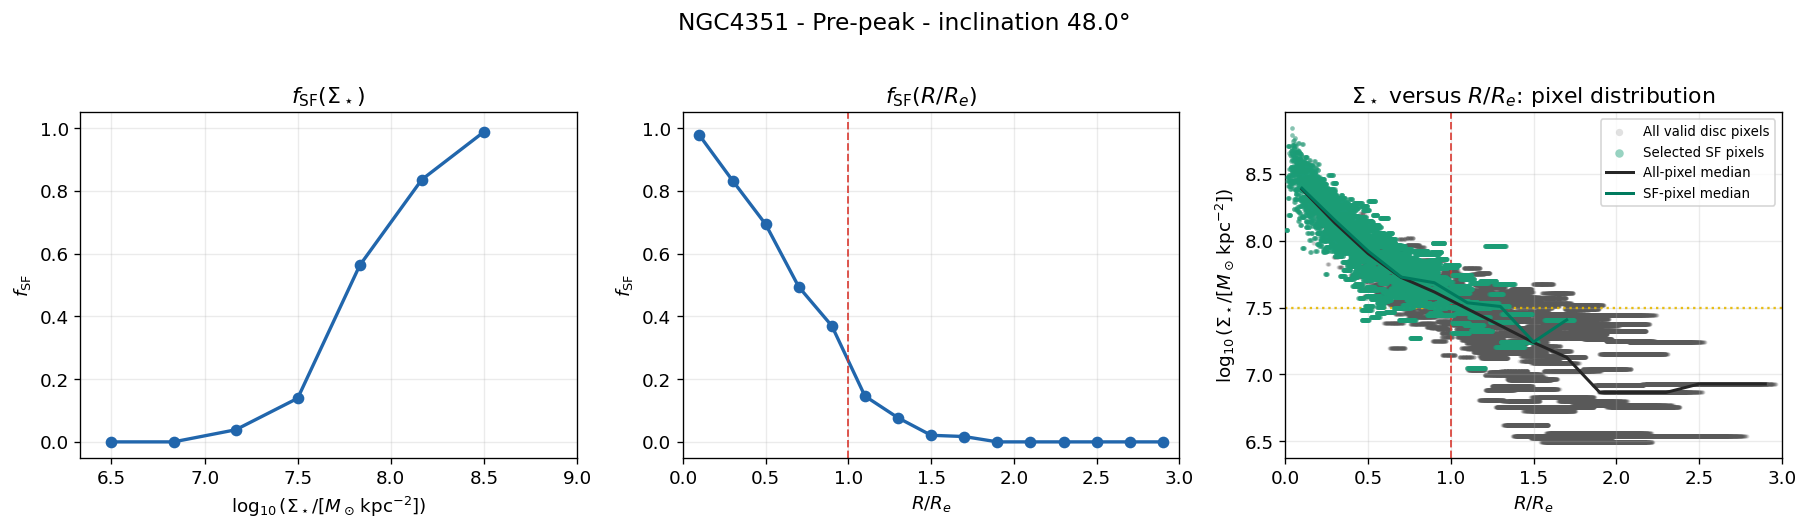

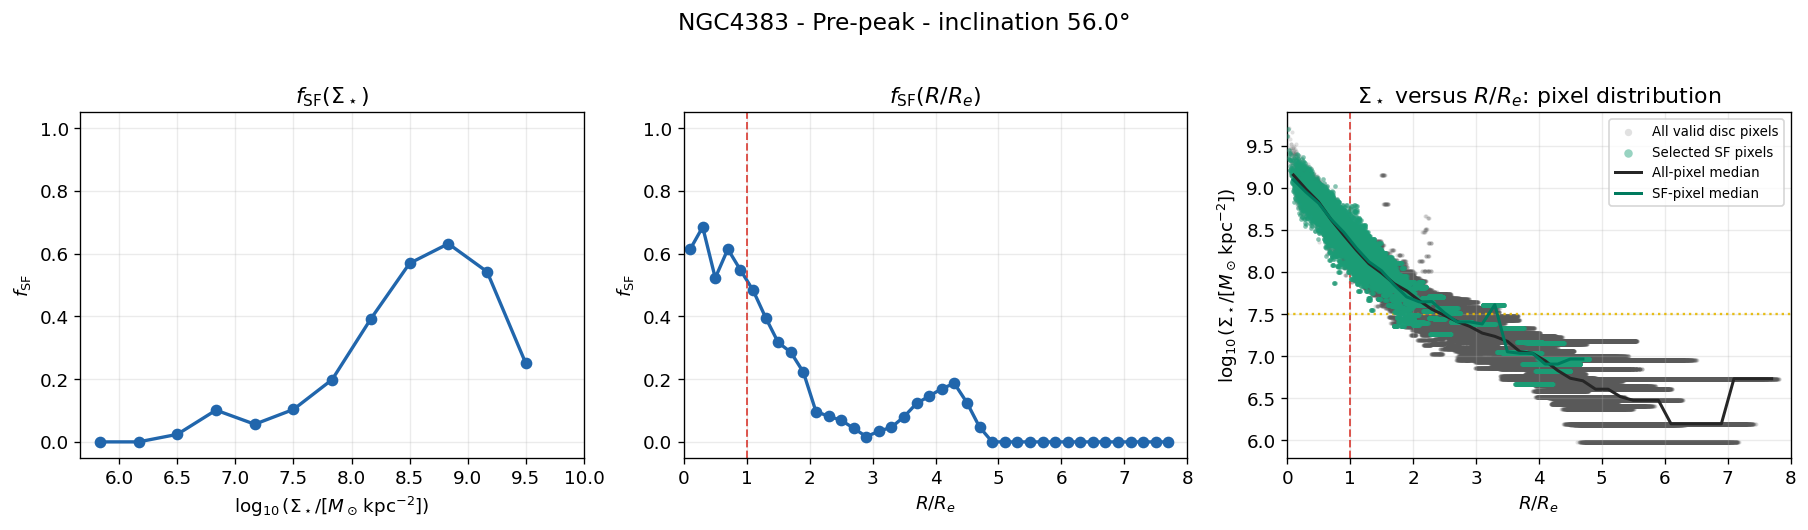

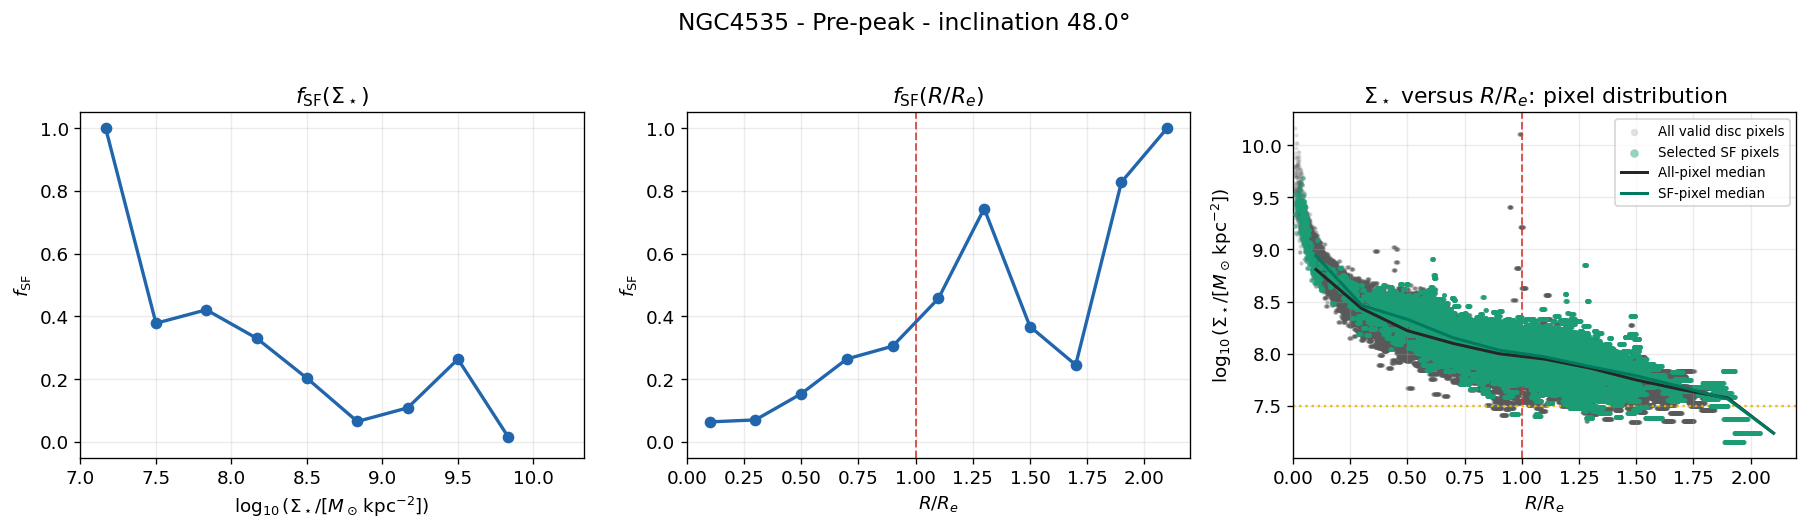

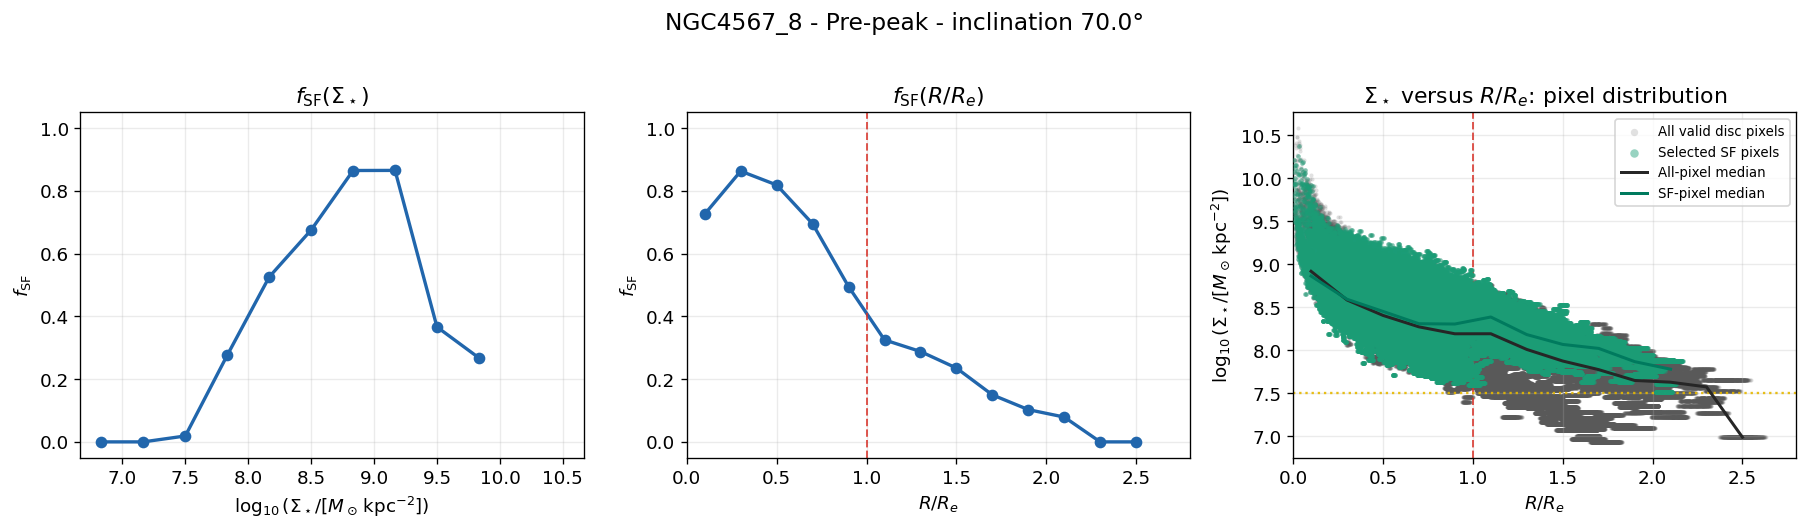

In [5]:
# Recreate the cell 9 diagnostics with the full pixel distributions in panel 3.
for row in prepeak.itertuples(index=False):
    maps = map_cache[row.GALID]
    measurements = individual_measurements[row.GALID]
    by_sigma = measurements["fSF_by_sigma"]
    by_radius = measurements["fSF_by_radius"]
    mass_by_radius = measurements["mass_by_radius"]
    galaxy_sigma_edges = measurements["sigma_edges"]
    galaxy_radius_edges = measurements["radius_edges"]

    fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.3))
    fig.suptitle(
        f"{row.GALID} - Pre-peak - inclination {row.inclination:.1f}°",
        fontsize=14, y=1.02,
    )

    axes[0].plot(by_sigma.center, by_sigma.f_SF, marker="o", lw=2.0, color="#2166ac")
    axes[0].set(
        xlabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        ylabel=r"$f_{\rm SF}$",
        title=r"$f_{\rm SF}(\Sigma_\star)$",
        xlim=(galaxy_sigma_edges[0], galaxy_sigma_edges[-1]), ylim=(-0.05, 1.05),
    )
    axes[1].plot(by_radius.center, by_radius.f_SF, marker="o", lw=2.0, color="#2166ac")
    axes[1].set(
        xlabel=r"$R/R_e$", ylabel=r"$f_{\rm SF}$",
        title=r"$f_{\rm SF}(R/R_e)$",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]), ylim=(-0.05, 1.05),
    )
    axes[1].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8)

    all_pixels = maps["valid_disc_mask"]
    sf_pixels = maps["sf_mask"]
    axes[2].scatter(
        maps["radius_re"][all_pixels], maps["log_sigma_star"][all_pixels],
        s=6, color="0.35", alpha=0.18, linewidths=0, rasterized=True, zorder=1,
        label="All valid disc pixels",
    )
    axes[2].scatter(
        maps["radius_re"][sf_pixels], maps["log_sigma_star"][sf_pixels],
        s=8, color="#1b9e77", alpha=0.45, linewidths=0, rasterized=True, zorder=3,
        label="Selected SF pixels",
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.all_median,
        lw=1.8, color="0.15", zorder=4, label="All-pixel median",
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.sf_median,
        lw=1.8, color="#007a5e", zorder=5, label="SF-pixel median",
    )
    axes[2].set(
        xlabel=r"$R/R_e$",
        ylabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        title=r"$\Sigma_\star$ versus $R/R_e$: pixel distribution",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]),
    )
    axes[2].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8, zorder=2)
    axes[2].axhline(
        MASS_CONTOUR_LEVEL, color="#e6b800", ls=":", lw=1.4, alpha=0.9, zorder=2
    )
    axes[2].legend(fontsize=8, markerscale=1.8)

    for axis in axes:
        axis.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

## 5. Pre-peak stellar-mass maps with $R_e$ and $\log\Sigma_\star=7.5$ boundaries

The map styling follows cell 7 of the 2026-08-20 source notebook: grayscale stellar mass, the selected H II-region SFR overlay, and a red $R_e$ boundary. The new yellow contour marks the boundary at $\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])=7.5$.

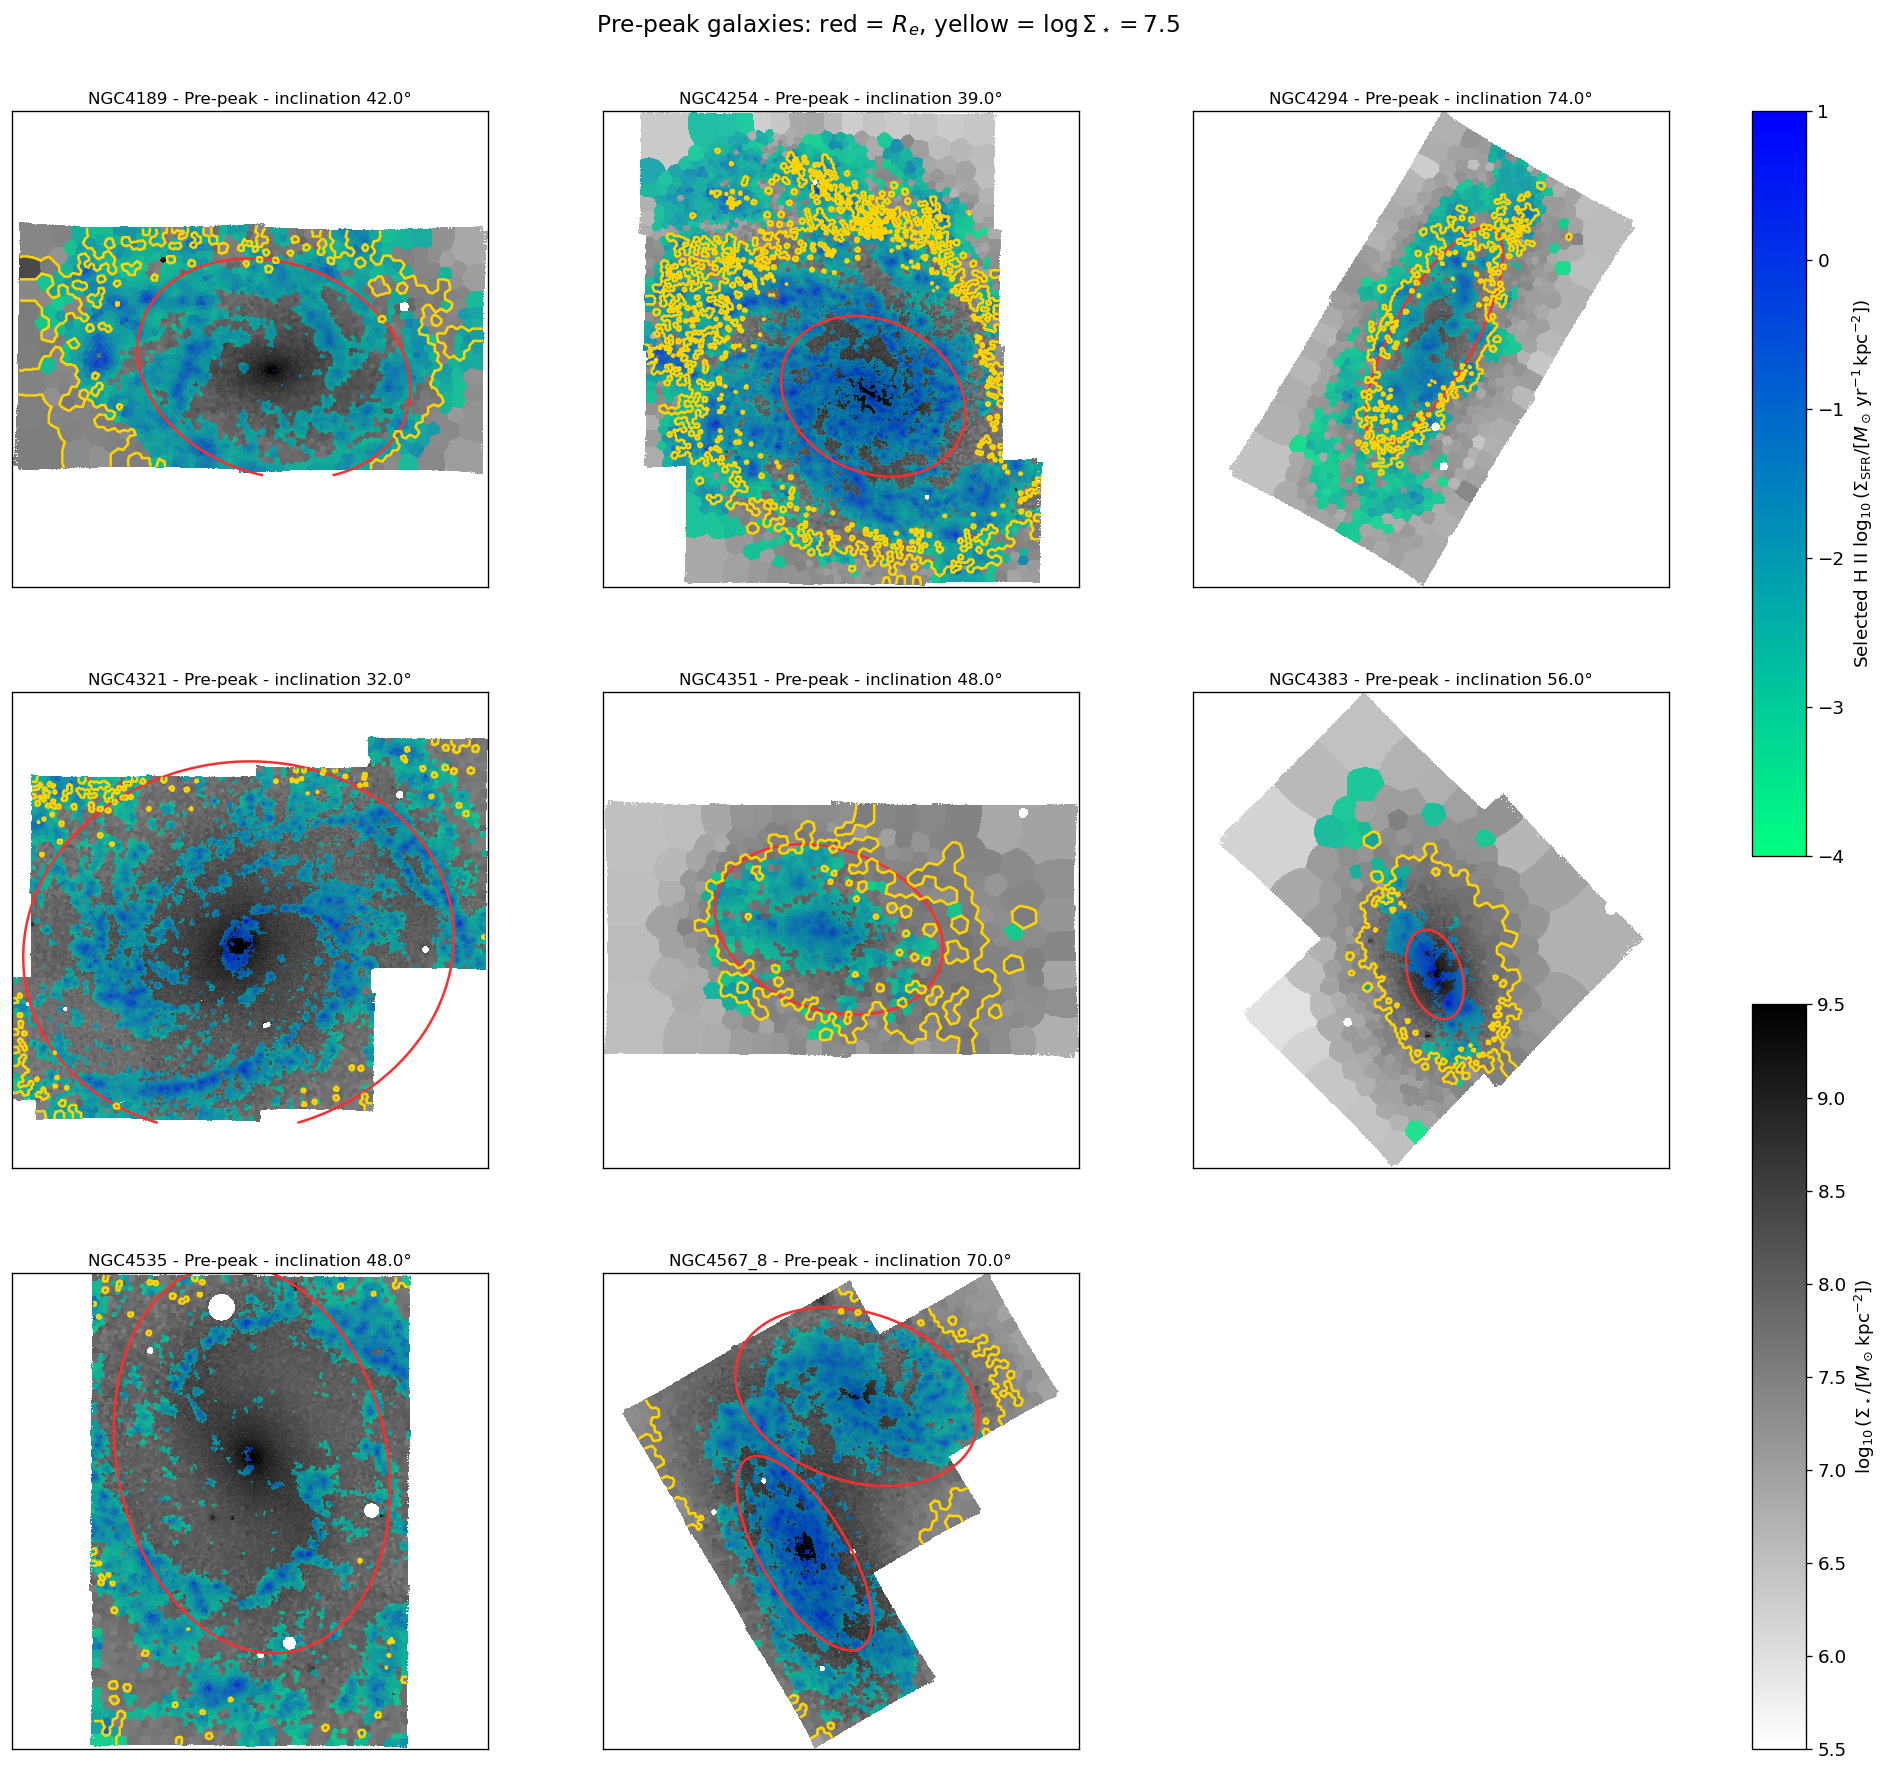

,GALID,inclination_deg,N_valid_pixels,N_selected_SF_pixels,N_finite_mass_pixels_ge_7p5,Re_boundary_drawn,logSigmaStar_7p5_boundary_drawn
0,NGC4189,42.0,177204,96364,130272,True,True
1,NGC4254,39.0,1043477,661963,592173,True,True
2,NGC4294,74.0,179355,68833,37438,True,True
3,NGC4321,32.0,970159,454131,949452,True,True
4,NGC4351,48.0,180133,30711,62947,True,True
5,NGC4383,56.0,227031,25212,53129,True,True
6,NGC4535,48.0,525101,187113,518545,True,True
7,NGC4567_8,70.0,510118,222533,457194,True,True


In [6]:
ncols = min(3, len(prepeak))
nrows = math.ceil(len(prepeak) / ncols)

# Match the reference notebook: maps occupy the main grid and the two vertical
# colorbars share a narrow right-hand column, with SFR above stellar mass.
fig = plt.figure(figsize=(5.1 * ncols + 0.8, 5.0 * nrows), constrained_layout=False)
map_grid = fig.add_gridspec(
    nrows, ncols + 1, width_ratios=[1] * ncols + [0.10]
)
axes = np.asarray([
    [fig.add_subplot(map_grid[row_index, column_index]) for column_index in range(ncols)]
    for row_index in range(nrows)
])
colorbar_grid = map_grid[:, ncols].subgridspec(2, 1, hspace=0.20)
sfr_colorbar_axis = fig.add_subplot(colorbar_grid[0, 0])
mass_colorbar_axis = fig.add_subplot(colorbar_grid[1, 0])

mass_norm = mpl.colors.Normalize(vmin=5.5, vmax=9.5)
sfr_norm = mpl.colors.Normalize(vmin=-4.0, vmax=1.0)
sfr_cmap = mpl.colormaps["winter_r"].copy()
sfr_cmap.set_bad((0.0, 0.0, 0.0, 0.0))

map_audit_rows = []
for axis, row in zip(axes.ravel(), prepeak.itertuples(index=False)):
    maps = map_cache[row.GALID]
    mass = maps["log_sigma_star"]
    radius = maps["radius_re"]
    sfr_overlay = np.ma.masked_where(~maps["sf_mask"], maps["log_sigma_sfr"])

    axis.imshow(mass, origin="lower", cmap="gray_r", norm=mass_norm, interpolation="nearest")
    axis.imshow(
        sfr_overlay, origin="lower", cmap=sfr_cmap, norm=sfr_norm,
        interpolation="nearest", alpha=0.82,
    )
    re_contour = axis.contour(
        radius, levels=[1.0], colors="#ff2d2d", linewidths=1.5, origin="lower"
    )
    sigma_contour = axis.contour(
        mass, levels=[MASS_CONTOUR_LEVEL], colors="#ffd400", linewidths=1.5, origin="lower"
    )
    axis.set_title(
        f"{row.GALID} - Pre-peak - inclination {row.inclination:.1f}°",
        fontsize=10, pad=4,
    )
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_box_aspect(1)
    map_audit_rows.append({
        "GALID": row.GALID,
        "inclination_deg": row.inclination,
        "N_valid_pixels": int(maps["valid_disc_mask"].sum()),
        "N_selected_SF_pixels": int(maps["sf_mask"].sum()),
        "N_finite_mass_pixels_ge_7p5": int((np.isfinite(mass) & (mass >= MASS_CONTOUR_LEVEL)).sum()),
        "Re_boundary_drawn": bool(len(re_contour.allsegs[0]) > 0),
        "logSigmaStar_7p5_boundary_drawn": bool(len(sigma_contour.allsegs[0]) > 0),
    })

for axis in axes.ravel()[len(prepeak):]:
    axis.axis("off")

mass_sm = mpl.cm.ScalarMappable(norm=mass_norm, cmap="gray_r")
sfr_sm = mpl.cm.ScalarMappable(norm=sfr_norm, cmap=sfr_cmap)
sfr_cbar = fig.colorbar(sfr_sm, cax=sfr_colorbar_axis)
sfr_cbar.set_label(
    r"Selected H II $\log_{10}(\Sigma_{\rm SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$"
)
mass_cbar = fig.colorbar(mass_sm, cax=mass_colorbar_axis)
mass_cbar.set_label(r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$")

fig.suptitle(
    r"Pre-peak galaxies: red = $R_e$, yellow = $\log\Sigma_\star=7.5$",
    fontsize=14, y=0.995,
)
fig.subplots_adjust(left=0.03, right=0.975, bottom=0.03, top=0.94, wspace=0.12, hspace=0.22)
PREPEAK_MAP_AUDIT = pd.DataFrame(map_audit_rows)
plt.show()
display(PREPEAK_MAP_AUDIT)

## Final scope note

This notebook intentionally contains no close-to-peak or post-peak comparisons, no pooled stage summary, no leave-one-galaxy-out calculation, and no file-saving calls. Its outputs are the individual pre-peak diagnostic figures, the pre-peak map grid, and the in-notebook QC/audit tables.